# Linear Regression — From Intuition to Diagnostics
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

In this notebook we build **Linear Regression** from first principles, fit
models with `statsmodels`, read the OLS summary line by line, run a full
battery of **regression diagnostics**, and finish with **remedial measures**
when assumptions are violated.

> This notebook is meant to be read *and* run top to bottom. Re-run each code
> cell yourself and try to predict the output before looking at it.

## Learning Objectives

By the end of this notebook you should be able to:

1. Explain **what a regression problem is** and when linear regression is an
   appropriate tool.
2. Describe the **five core assumptions** of linear regression (the *LINEM*
   acronym).
3. Derive the **Ordinary Least Squares (OLS)** estimator intuitively and
   explain **why setting the derivative to zero finds the minimum**.
4. Fit a multiple linear regression model with **`statsmodels`** and
   interpret every block of the OLS summary table.
5. Run **regression diagnostics** — residual plots, Q–Q plot, residual
   histogram, VIF, Cook's distance, Breusch–Pagan, Shapiro–Wilk, Durbin–Watson.
6. Apply **remedial measures** (transformations, polynomial features,
   dropping collinear features) when diagnostics reveal problems.

## 1. What is a Regression Problem?

In **supervised learning** we are given pairs $(x_i, y_i)$ and want to learn a
function $f$ such that $\hat{y} = f(x)$ is a good prediction of $y$.

| Task type       | Output $y$            | Example                                 |
|-----------------|-----------------------|-----------------------------------------|
| **Regression**  | continuous number     | predict house price, sales, temperature |
| **Classification** | discrete label     | spam / not spam, cat / dog / bird       |

**Linear regression** is the simplest, most interpretable regression model:
we assume $y$ is (approximately) a **straight-line / flat-plane** function of
the inputs plus some random noise.

### Simple vs. Multiple Linear Regression

- **Simple linear regression** — one predictor:
  $$y = \beta_0 + \beta_1 x + \varepsilon$$
- **Multiple linear regression** — many predictors:
  $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \varepsilon$$

The symbol $\varepsilon$ ("epsilon") is the **irreducible error** — the part
of $y$ that we cannot explain with the predictors.

## 2. Setting Up — Importing Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)   # for reproducibility

## 3. Building Intuition — "The Best Fit Line"

Before we touch any real data, let's understand the core question that
linear regression answers:

> *"Given a cloud of points, which straight line passes closest to all of
> them at the same time?"*

We'll make a tiny toy dataset so we can draw lines by hand.

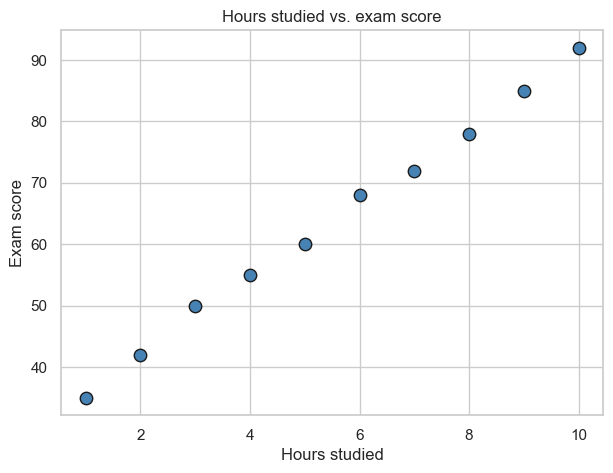

In [28]:
# Toy dataset: hours studied vs. exam score
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
score = np.array([35, 42, 50, 55, 60, 68, 72, 78, 85, 92], dtype=float)

plt.figure(figsize=(7, 5))
plt.scatter(hours, score, s=80, color="steelblue", edgecolor="k")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Hours studied vs. exam score")
plt.show()

### What is a residual?

Any candidate line $\hat y = \beta_0 + \beta_1 x$ will, in general, *not* pass
through the points exactly. For every point $(x_i, y_i)$ the **residual** is

$$e_i = y_i - \hat{y}_i = y_i - (\beta_0 + \beta_1 x_i)$$

That is: **actual minus predicted**. The residual is the *vertical distance*
from the point to the line.

Let's draw a (deliberately bad) line and show the residuals.

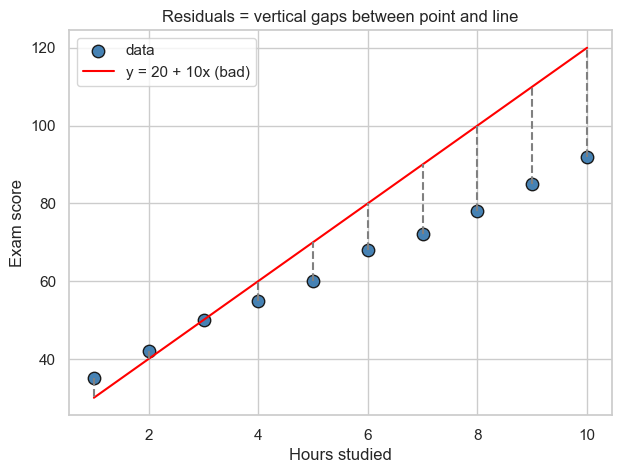

In [29]:
# A deliberately bad line
b0_bad, b1_bad = 20, 10
y_bad = b0_bad + b1_bad * hours

plt.figure(figsize=(7, 5))
plt.scatter(hours, score, s=80, color="steelblue", edgecolor="k", label="data")
plt.plot(hours, y_bad, color="red", label=f"y = {b0_bad} + {b1_bad}x (bad)")
for xi, yi, yhat in zip(hours, score, y_bad):
    plt.plot([xi, xi], [yi, yhat], color="gray", linestyle="--")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Residuals = vertical gaps between point and line")
plt.legend()
plt.show()

### Measuring how bad a line is — Sum of Squared Errors (SSE)

We want a single number that says *"how bad is this line overall?"*. The
obvious idea is to add up all the residuals — but positive and negative
residuals would cancel out. Two common fixes:

1. **Absolute values:** $\sum_i |e_i|$ — leads to **Least Absolute Deviations**.
2. **Squares:** $\sum_i e_i^2$ — leads to **Ordinary Least Squares (OLS)**.

OLS is the classic choice because:

- **Larger errors are penalized more** (a residual of 10 contributes 100,
  not 10). The line is pulled harder towards distant points.
- The squared function is **smooth and differentiable everywhere** — we can
  use calculus to find the minimum in closed form.
- Under the Gauss–Markov assumptions, OLS is the **Best Linear Unbiased
  Estimator (BLUE)** — the most efficient linear estimator.

The quantity we minimize is

$$\text{SSE}(\beta_0, \beta_1) \;=\; \sum_{i=1}^n \bigl(y_i - \beta_0 - \beta_1 x_i\bigr)^2$$

In [30]:
def sse(b0, b1, x, y):
    return np.sum((y - (b0 + b1 * x)) ** 2)

print(f"SSE of the bad line (b0=20, b1=10): {sse(20, 10, hours, score):.2f}")
print(f"SSE of another guess (b0=30, b1=6):  {sse(30, 6, hours, score):.2f}")
print(f"SSE of a better guess (b0=27, b1=6.3): {sse(27, 6.3, hours, score):.2f}")

SSE of the bad line (b0=20, b1=10): 2515.00
SSE of another guess (b0=30, b1=6):  15.00
SSE of a better guess (b0=27, b1=6.3): 52.65


## 4. Deriving OLS — Why the Derivative Equals Zero at the Minimum

SSE is a function of $\beta_0$ and $\beta_1$. If we fix $\beta_0$ for a moment
and vary $\beta_1$, the SSE traces out a **parabola** (a bowl shape).

We want the **bottom of the bowl**. How do we find it?

### The core calculus idea

Look at a smooth curve. At every point the curve has a *slope* (derivative).

- If the slope is **positive**, the curve is still going up — we could move
  **left** and get a smaller value. So this is not yet the minimum.
- If the slope is **negative**, the curve is still going down — we could move
  **right** and get a smaller value. So this is not the minimum either.
- At the **minimum**, there is **no direction** in which we can decrease the
  function. The curve must be momentarily **flat**, i.e. the slope is **zero**.

> **Key insight:** at a minimum of a smooth function, the derivative is $0$.

That is why we find the minimum of SSE by **setting the derivative equal to
zero and solving**. Let's see this visually first.

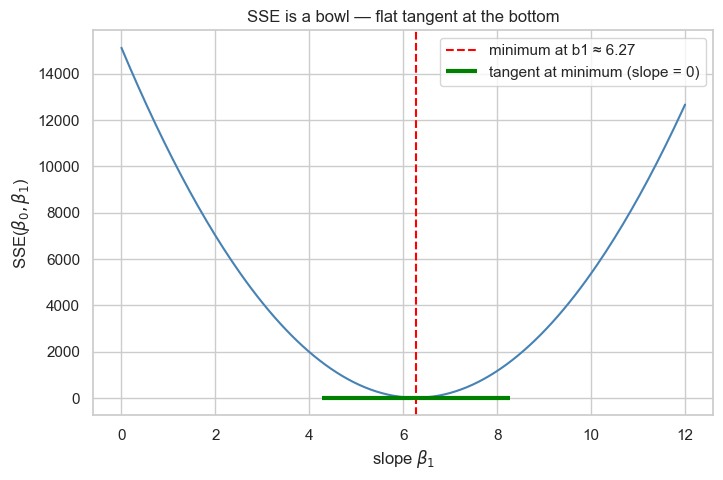

In [31]:
# Plot SSE as a function of b1 (holding b0 fixed at the true intercept)
b0_fixed = score.mean() - 6.3 * hours.mean()  # approx best b0 given b1=6.3
b1_range = np.linspace(0, 12, 200)
sse_vals = [sse(b0_fixed, b1, hours, score) for b1 in b1_range]

b1_min_idx = int(np.argmin(sse_vals))
b1_min = b1_range[b1_min_idx]

plt.figure(figsize=(8, 5))
plt.plot(b1_range, sse_vals, color="steelblue")
plt.axvline(b1_min, color="red", linestyle="--",
            label=f"minimum at b1 ≈ {b1_min:.2f}")
# Tangent line at the minimum — horizontal because slope = 0
plt.hlines(sse_vals[b1_min_idx],
           b1_min - 2, b1_min + 2,
           color="green", linewidth=3,
           label="tangent at minimum (slope = 0)")
plt.xlabel(r"slope $\beta_1$")
plt.ylabel(r"SSE($\beta_0, \beta_1$)")
plt.title("SSE is a bowl — flat tangent at the bottom")
plt.legend()
plt.show()

### Doing the calculus

Start with
$$\text{SSE}(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2.$$

Take partial derivatives and set each to zero — these are the **normal
equations**:

$$\frac{\partial \text{SSE}}{\partial \beta_0} = -2 \sum_i (y_i - \beta_0 - \beta_1 x_i) = 0$$

$$\frac{\partial \text{SSE}}{\partial \beta_1} = -2 \sum_i x_i (y_i - \beta_0 - \beta_1 x_i) = 0$$

The first equation says the residuals **sum to zero**. The second says the
residuals are **uncorrelated with the predictor**. Solving for
$\beta_0, \beta_1$:

$$\boxed{\;\hat\beta_1 = \frac{\sum_i (x_i - \bar x)(y_i - \bar y)}{\sum_i (x_i - \bar x)^2} = \frac{\operatorname{cov}(x, y)}{\operatorname{var}(x)}\;}$$

$$\boxed{\;\hat\beta_0 = \bar y - \hat\beta_1 \bar x\;}$$

### Multiple linear regression (matrix form)

With $p$ predictors, stack the data into a matrix $X$ (shape $n \times (p+1)$,
first column all ones for the intercept) and a vector $y$. SSE becomes

$$\text{SSE}(\boldsymbol\beta) = (y - X\boldsymbol\beta)^\top (y - X\boldsymbol\beta).$$

Setting the gradient to zero gives the celebrated **normal equation**

$$\boxed{\;\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top y\;}$$

Let's verify these formulas by computing OLS **from scratch** and comparing
against `statsmodels`.

In [32]:
# OLS from scratch — simple linear regression
x_bar, y_bar = hours.mean(), score.mean()
b1_hat = np.sum((hours - x_bar) * (score - y_bar)) / np.sum((hours - x_bar) ** 2)
b0_hat = y_bar - b1_hat * x_bar
print(f"From scratch:  b0 = {b0_hat:.4f},  b1 = {b1_hat:.4f}")

# Same thing via statsmodels
X_sm = sm.add_constant(hours)
sm_fit = sm.OLS(score, X_sm).fit()
print(f"statsmodels:   b0 = {sm_fit.params[0]:.4f},  b1 = {sm_fit.params[1]:.4f}")

From scratch:  b0 = 29.9333,  b1 = 6.1394
statsmodels:   b0 = 29.9333,  b1 = 6.1394


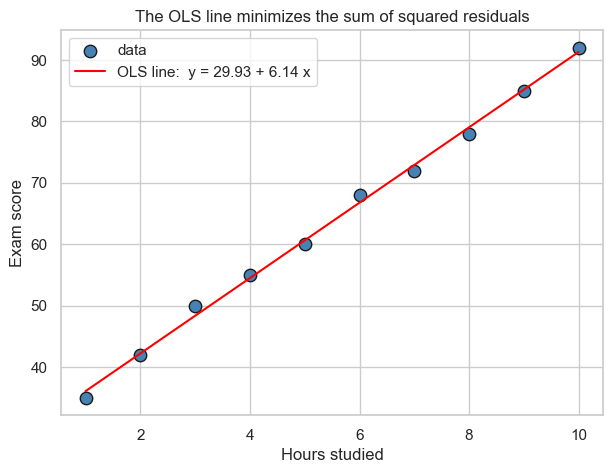

In [33]:
# Draw the fitted line on top of the data
plt.figure(figsize=(7, 5))
plt.scatter(hours, score, s=80, color="steelblue", edgecolor="k", label="data")
xs = np.linspace(hours.min(), hours.max(), 100)
plt.plot(xs, b0_hat + b1_hat * xs, color="red",
         label=f"OLS line:  y = {b0_hat:.2f} + {b1_hat:.2f} x")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("The OLS line minimizes the sum of squared residuals")
plt.legend()
plt.show()

## 5. A Real Dataset — Advertising Spend vs. Sales

We'll use the classic **Advertising** dataset from *An Introduction to
Statistical Learning* (James, Witten, Hastie, Tibshirani). Each of 200 rows
is a market, with how many (thousand) dollars were spent on **TV**, **radio**
and **newspaper** ads, and the resulting **sales** (in thousands of units).

**Business question:** How does each advertising channel contribute to sales,
and can we predict sales from an advertising budget?

In [34]:
# Try local copy first, fall back to the ISLR mirror
try:
    data = pd.read_csv('../datasets/Advertising.csv', index_col=0)
except FileNotFoundError:
    data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv',
                       index_col=0)
data.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [35]:
data.shape

(200, 4)

In [36]:
data.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 6. Exploratory Data Analysis

Before fitting, look at:

- **Correlations** — which predictors move with `sales`? Do any predictors
  move with *each other* (a warning sign for multicollinearity)?
- **Scatter plots** — is the relationship plausibly linear?

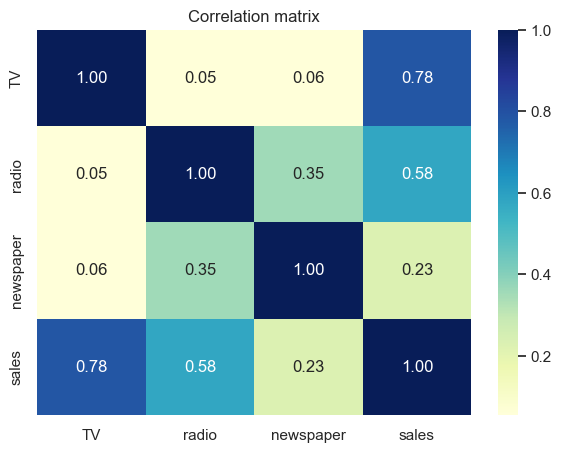

In [37]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu",
            annot=True, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

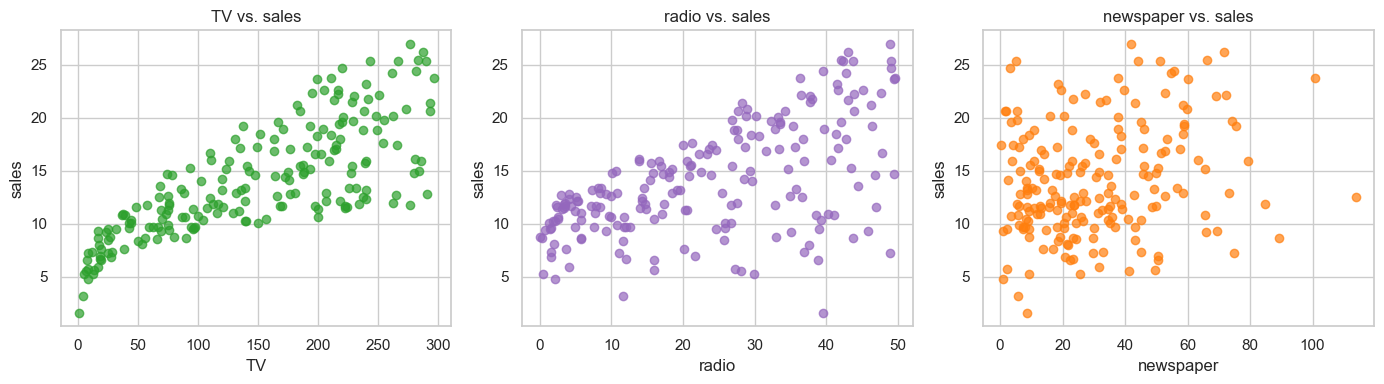

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['TV', 'radio', 'newspaper'],
                          ['tab:green', 'tab:purple', 'tab:orange']):
    ax.scatter(data[col], data['sales'], color=color, alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('sales')
    ax.set_title(f'{col} vs. sales')
plt.tight_layout()
plt.show()

**What to notice**

- `TV` has the strongest (and clearly linear) relationship with `sales`.
- `radio` is moderately correlated with sales.
- `newspaper` is only weakly correlated with sales and is also somewhat
  correlated with `radio` — already a hint of multicollinearity.

## 7. The Assumptions of Linear Regression

Linear regression is only *statistically* trustworthy when a short list of
assumptions hold. A convenient mnemonic is **LINEM**:

| Letter | Assumption | Plain-English meaning |
|---|---|---|
| **L** | **Linearity** | The true relationship between $X$ and $y$ is linear. |
| **I** | **Independence** | Observations (and errors) are independent of each other. No autocorrelation. |
| **N** | **Normality** | The residuals are approximately Normally distributed. |
| **E** | **Equal variance** | The spread of residuals is constant across fitted values (**homoscedasticity**). |
| **M** | **No Multicollinearity** | Predictors are not (almost) linear combinations of each other. |

Each assumption has a **diagnostic** that can detect its violation and a
**remedy** that often fixes it. We will see all of them in action.

## 8. Fitting Multiple Linear Regression with `statsmodels`

`statsmodels` is the go-to library for *statistical* regression in Python
(`sklearn` is optimized for *prediction* and gives you fewer diagnostics).

Two important details:

1. `statsmodels` does **not** add an intercept for you. You must call
   `sm.add_constant(X)` to get a column of ones.
2. The call pattern is `sm.OLS(y, X).fit()` — **`y` comes first**.

In [39]:
X = data[['TV', 'radio', 'newspaper']]
y = data['sales']

X_const = sm.add_constant(X)
X_const.head(3)

,const,TV,radio,newspaper
1,1.0,230.1,37.8,69.2
2,1.0,44.5,39.3,45.1
3,1.0,17.2,45.9,69.3


In [40]:
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           1.58e-96
Time:                        21:19:14   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

## 9. Reading the OLS Summary — Block by Block

The summary table looks intimidating, but every number has a job.

### Top block — model-level statistics

| Field | What it means |
|---|---|
| **Dep. Variable** | The column we are predicting (`sales`). |
| **Model** | `OLS` — Ordinary Least Squares. |
| **No. Observations** | $n$ — number of rows used. |
| **Df Residuals** | $n - p - 1$ — degrees of freedom for residuals. |
| **Df Model** | $p$ — number of predictors (not counting the intercept). |
| **R-squared** | Fraction of variance in $y$ explained by the model: $1 - \text{SSE}/\text{SST}$. Ranges $[0, 1]$. |
| **Adj. R-squared** | R² penalized for adding predictors. Use this when comparing models with different numbers of features. |
| **F-statistic / Prob (F-stat)** | Tests $H_0$: *all slopes are zero*. Small p-value ⇒ the model is jointly useful. |
| **Log-Likelihood / AIC / BIC** | Used to compare alternative models (lower AIC/BIC is better). |

### Middle block — per-coefficient table

| Column | What it means |
|---|---|
| **coef** | $\hat\beta_j$ — the estimated slope. "Holding everything else fixed, a one-unit increase in $x_j$ changes the prediction by this much." |
| **std err** | Standard error of $\hat\beta_j$ — our uncertainty about the slope. |
| **t** | $\hat\beta_j / \text{std err}$ — the $t$-statistic. |
| **P>\|t\|** | Two-sided p-value for $H_0: \beta_j = 0$. Small ⇒ the predictor is *statistically significant*. |
| **[0.025, 0.975]** | 95% confidence interval for $\beta_j$. If it crosses zero, the coefficient is not significant at the 5% level. |

### Bottom block — diagnostics baked into the summary

| Field | What it means |
|---|---|
| **Omnibus / Prob(Omnibus)** | Joint test of skewness + kurtosis of residuals. Small p-value ⇒ non-normal residuals. |
| **Skew** | Asymmetry of residuals. 0 = symmetric. |
| **Kurtosis** | "Tailedness". 3 = Normal. |
| **Jarque–Bera / Prob(JB)** | Another normality test, based on skew and kurtosis. |
| **Durbin–Watson** | Autocorrelation of residuals. ≈ 2 is good. < 1.5 or > 2.5 is suspicious. |
| **Cond. No.** | Condition number of $X^\top X$. Very large (> 30) ⇒ possible multicollinearity or ill-scaled features. |

### What does our model say?

- $R^2 \approx 0.90$: the three ad channels jointly explain about 90% of the
  variance in sales. Very good.
- **TV** ($p < 0.001$) and **radio** ($p < 0.001$) are strongly significant.
- **newspaper** has a coefficient close to zero and a *very* large p-value —
  once TV and radio are in the model, newspaper adds essentially nothing.
- Durbin–Watson $\approx 2$: no obvious autocorrelation.
- Omnibus / JB p-values are tiny ⇒ residuals may not be perfectly Normal —
  we will check this visually in a moment.

## 10. Regression Diagnostics

The summary tells us *whether* the model fits. Diagnostics tell us *whether
we are allowed to trust the summary*.

We'll compute the residuals once and reuse them.

In [41]:
y_pred = ols_model.predict(X_const)
residuals = y - y_pred
residuals.describe()

count    2.000000e+02
mean     5.506706e-16
std      1.672757e+00
min     -8.827687e+00
25%     -8.908135e-01
50%      2.418018e-01
75%      1.189319e+00
max      2.829223e+00
dtype: float64

### 10.1 Residuals vs. Fitted — *Linearity* and *Homoscedasticity*

Plot residuals on the $y$-axis against fitted values on the $x$-axis.

**What to look for:**

- **Linearity:** residuals should scatter *randomly around zero* with no
  curved trend. A U-shape or inverted-U means the relationship is not
  really linear.
- **Equal variance:** the vertical spread should be roughly **the same**
  across the whole $x$-range. A *fanning out* pattern signals
  **heteroscedasticity**.

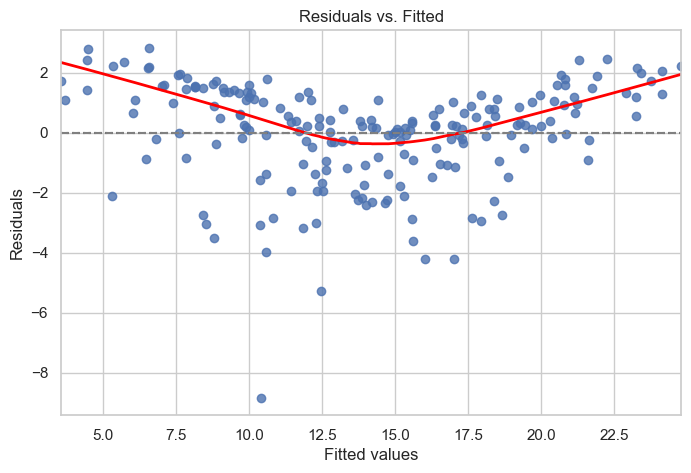

In [42]:
plt.figure(figsize=(8, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 2})
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

Notice the **slight curvature** of the red LOWESS line and the **lower
tail** of large negative residuals on the left — the model underpredicts
small sales and the relationship has a mild non-linear component
(interaction between TV and radio is the real culprit).

### 10.2 Q–Q Plot — *Normality of residuals*

A Quantile–Quantile plot compares the quantiles of the residuals to the
quantiles of a standard Normal. If the residuals are Normally distributed,
the points lie on the 45° line.

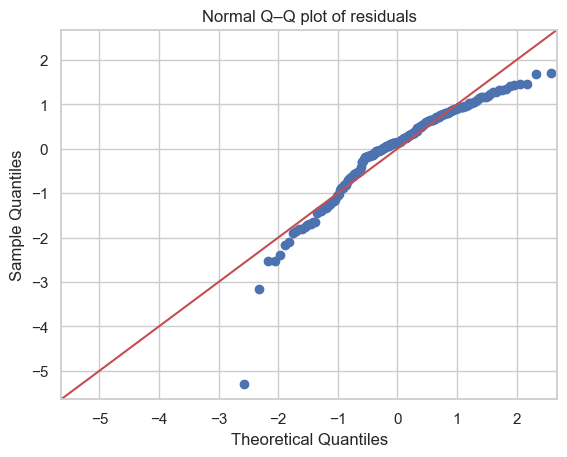

In [43]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Normal Q–Q plot of residuals")
plt.show()

### 10.3 Histogram / density of residuals

Another way to eyeball normality. We also overlay a Normal curve with the
same mean and std for reference.

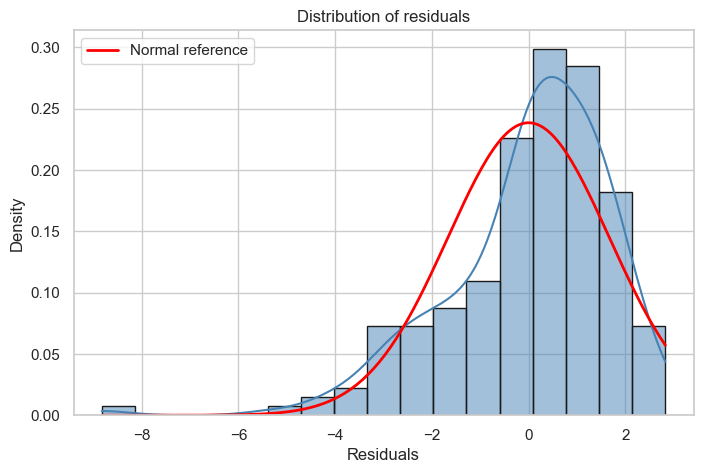

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, stat='density',
             color='steelblue', edgecolor='k')
xs = np.linspace(residuals.min(), residuals.max(), 200)
plt.plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()),
         color='red', lw=2, label='Normal reference')
plt.xlabel('Residuals')
plt.title('Distribution of residuals')
plt.legend()
plt.show()

### 10.4 Scale–Location plot — equal variance, another angle

This plots $\sqrt{|\text{standardized residual}|}$ vs. fitted value. A
**flat horizontal** trend means constant variance.

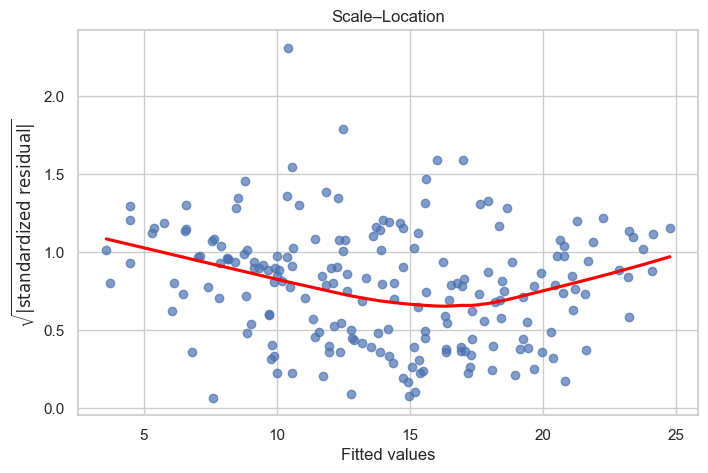

In [45]:
influence = ols_model.get_influence()
std_resid = influence.resid_studentized_internal

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, np.sqrt(np.abs(std_resid)), alpha=0.7)
sns.regplot(x=y_pred, y=np.sqrt(np.abs(std_resid)),
            scatter=False, lowess=True,
            line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel(r'$\sqrt{|\mathrm{standardized\ residual}|}$')
plt.title('Scale–Location')
plt.show()

### 10.5 Variance Inflation Factor (VIF) — multicollinearity

**Multicollinearity** happens when one predictor can be (almost) predicted
from the others. It **inflates the variance** of the coefficient estimates,
making individual p-values unreliable — the overall $R^2$ can still be high
while each individual coefficient looks useless.

The VIF for predictor $j$ is
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
where $R_j^2$ is the $R^2$ of regressing $x_j$ on all *other* predictors.

**Rules of thumb:** VIF $< 5$ fine, $5$–$10$ suspicious, $> 10$ serious.

In [46]:
vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})
vif

,feature,VIF
0,TV,2.486772
1,radio,3.285462
2,newspaper,3.055245


All VIFs are comfortably below 5 — multicollinearity is not a serious
problem for this dataset.

### 10.6 Cook's Distance — influential observations

A point is **influential** if removing it would noticeably change the fitted
coefficients. Cook's distance combines *leverage* (how unusual $x_i$ is) and
*residual size*. A common rule of thumb flags observations with

$$D_i > \frac{4}{n}.$$

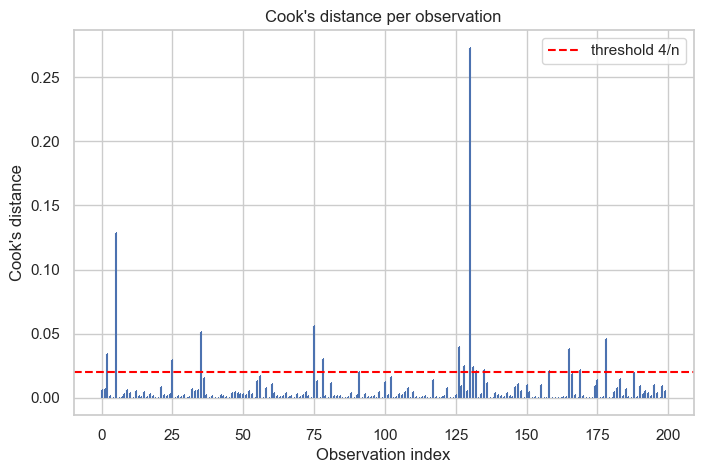

Observations above the 4/n threshold: [2, 5, 25, 35, 75, 78, 126, 128, 130, 131, 132, 135, 158, 165, 169, 178]


In [47]:
c, _ = influence.cooks_distance
n = len(c)

plt.figure(figsize=(8, 5))
plt.stem(np.arange(n), c, markerfmt=",", basefmt=" ")
plt.axhline(4 / n, color='red', linestyle='--',
            label='threshold 4/n')
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.title("Cook's distance per observation")
plt.legend()
plt.show()

print("Observations above the 4/n threshold:",
      np.where(c > 4 / n)[0].tolist())

### 10.7 Formal statistical tests

Plots are great for building intuition, but sometimes you want a number.
Three standard tests:

| Test | $H_0$ | Decision rule |
|---|---|---|
| **Breusch–Pagan** | errors are homoscedastic | reject if $p < 0.05$ ⇒ heteroscedastic |
| **Shapiro–Wilk**  | residuals are Normal | reject if $p < 0.05$ ⇒ non-Normal |
| **Durbin–Watson** | no autocorrelation | statistic $\approx 2$ = OK; near 0 = positive autocorrelation; near 4 = negative |

In [48]:
# Breusch-Pagan: homoscedasticity
bp = het_breuschpagan(residuals, X_const)
bp_labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
print("Breusch–Pagan:")
for lab, val in zip(bp_labels, bp):
    print(f"  {lab:10s} = {val:.4f}")
print("  -> p > 0.05 means we fail to reject homoscedasticity.\n")

# Shapiro-Wilk: normality
sw_stat, sw_p = stats.shapiro(residuals)
print(f"Shapiro–Wilk:  W = {sw_stat:.4f},  p = {sw_p:.3e}")
print("  -> p < 0.05 means residuals are NOT Normal.\n")

# Durbin-Watson: autocorrelation
dw = durbin_watson(residuals)
print(f"Durbin–Watson: DW = {dw:.4f}")
print("  -> Close to 2 means no autocorrelation.")

Breusch–Pagan:
  LM stat    = 5.1329
  LM p-value = 0.1623
  F stat     = 1.7209
  F p-value  = 0.1640
  -> p > 0.05 means we fail to reject homoscedasticity.

Shapiro–Wilk:  W = 0.9177,  p = 3.939e-09
  -> p < 0.05 means residuals are NOT Normal.

Durbin–Watson: DW = 2.0836
  -> Close to 2 means no autocorrelation.


### 10.8 A diagnostic summary

Let's collect everything into one compact verdict.

In [49]:
print("================ DIAGNOSTIC SUMMARY ================")
print(f"R²               : {ols_model.rsquared:.4f}")
print(f"Adjusted R²      : {ols_model.rsquared_adj:.4f}")
print(f"F-statistic p    : {ols_model.f_pvalue:.3e}")
print(f"Durbin–Watson    : {dw:.4f}  "
      f"({'OK' if 1.5 < dw < 2.5 else 'SUSPICIOUS'})")
print(f"Breusch–Pagan p  : {bp[1]:.4f}  "
      f"({'homoscedastic' if bp[1] > 0.05 else 'HETEROSCEDASTIC'})")
print(f"Shapiro–Wilk p   : {sw_p:.3e}  "
      f"({'normal' if sw_p > 0.05 else 'NOT normal'})")
print("VIFs:")
print(vif.to_string(index=False))
print("====================================================")

================ DIAGNOSTIC SUMMARY ================
R²               : 0.8972
Adjusted R²      : 0.8956
F-statistic p    : 1.575e-96
Durbin–Watson    : 2.0836  (OK)
Breusch–Pagan p  : 0.1623  (homoscedastic)
Shapiro–Wilk p   : 3.939e-09  (NOT normal)
VIFs:
  feature      VIF
       TV 2.486772
    radio 3.285462
newspaper 3.055245


## 11. Remedial Measures — What to Do When Assumptions Fail

A diagnostic only tells you *that* something is wrong. A **remedy** tells
you *what to do about it*. The table below maps each finding from
Section 10 to the most common fixes; the rest of this section walks through
the most useful ones with runnable code.

| Diagnostic finding | Likely violation | Common remedies |
|---|---|---|
| Curved residual-vs-fitted plot | **Non-linearity** | Polynomial features, interaction terms, $\log x$ / $\sqrt{x}$ transforms, splines |
| Fanning residual plot; Breusch–Pagan $p < 0.05$ | **Heteroscedasticity** | Log-transform $y$, Weighted Least Squares, HC-robust standard errors |
| Q–Q tails bend; Shapiro $p < 0.05$ | **Non-Normal residuals** | Transform $y$, investigate outliers, robust regression |
| VIF > 5 (some > 10) | **Multicollinearity** | Drop a redundant predictor, combine features, Ridge regression |
| Large Cook's distance | **Influential points** | Investigate the data, Huber robust regression (RLM), Winsorize |
| Durbin–Watson far from 2 | **Autocorrelation** | Lag features, ARIMA, Newey–West HAC standard errors |

**General rule:** fix the *most severe* violation first (usually
non-linearity), then re-run diagnostics. Remedies interact, so never apply
two at once without checking what each did.

### 11.1 Transforming the Response — $\log y$ for Heteroscedasticity

When the variance of the residuals **grows with the mean** (a "fan" shape
in the residual plot), a **log transform of $y$** often fixes it.
Intuition: $\log$ compresses large values more than small ones, so a
*multiplicative* error $y = e^{\beta_0 + \beta_1 x} \cdot e^{\varepsilon}$
becomes an *additive* one after taking logs:
$$\log y = \beta_0 + \beta_1 x + \varepsilon.$$

Let's simulate data that is truly log-linear, fit OLS naively, then fit OLS
on $\log y$ and compare diagnostics.

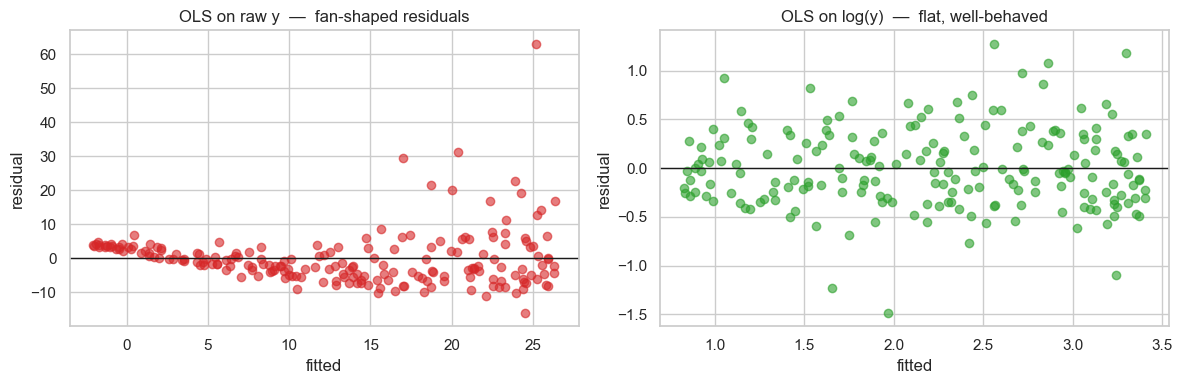

Breusch–Pagan p on raw y   : 5.8032e-03  (heteroscedastic)
Breusch–Pagan p on log y   : 2.5889e-01  (ok)


In [50]:
rng = np.random.default_rng(0)
n_sim = 200
x_h = rng.uniform(1, 10, n_sim)
# Multiplicative error: variance of y grows with its mean
y_h = np.exp(0.5 + 0.3 * x_h + rng.normal(0, 0.4, n_sim))

fit_raw = sm.OLS(y_h, sm.add_constant(x_h)).fit()
fit_log = sm.OLS(np.log(y_h), sm.add_constant(x_h)).fit()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(fit_raw.fittedvalues, fit_raw.resid, alpha=0.6, color='tab:red')
ax[0].axhline(0, color='k', lw=1)
ax[0].set(title='OLS on raw y  —  fan-shaped residuals',
          xlabel='fitted', ylabel='residual')

ax[1].scatter(fit_log.fittedvalues, fit_log.resid, alpha=0.6, color='tab:green')
ax[1].axhline(0, color='k', lw=1)
ax[1].set(title='OLS on log(y)  —  flat, well-behaved',
          xlabel='fitted', ylabel='residual')
plt.tight_layout()
plt.show()

bp_raw = het_breuschpagan(fit_raw.resid, sm.add_constant(x_h))[1]
bp_log = het_breuschpagan(fit_log.resid, sm.add_constant(x_h))[1]
print(f"Breusch\u2013Pagan p on raw y   : {bp_raw:.4e}  "
      f"({'heteroscedastic' if bp_raw < 0.05 else 'ok'})")
print(f"Breusch\u2013Pagan p on log y   : {bp_log:.4e}  "
      f"({'heteroscedastic' if bp_log < 0.05 else 'ok'})")

**Caveat — interpretation changes.** After log-transforming, the
coefficient of $x$ is no longer "units of $y$ per unit of $x$" but rather a
**percentage change**: a one-unit increase in $x$ multiplies $y$ by
$e^{\beta_1}$. Always report which transformation you used.

### 11.2 Polynomial Features — When the True Shape is Curved

Consider this toy dataset of reaction yield vs. temperature. A straight
line clearly won't fit — but a *cubic* polynomial will.

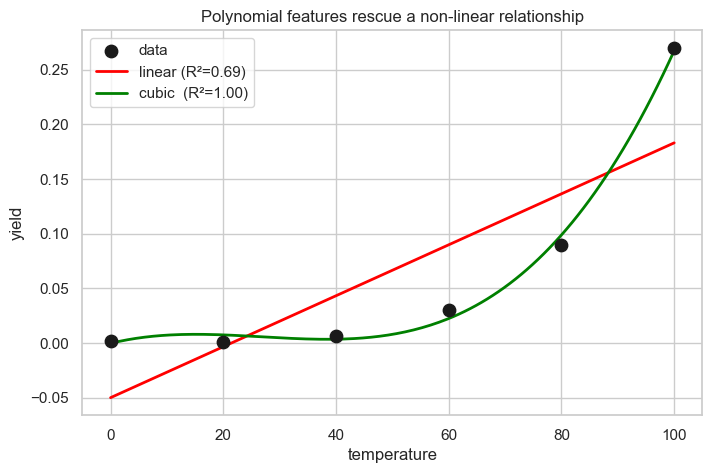

In [51]:
poly_data = pd.DataFrame({
    'temp':  [0, 20, 40, 60, 80, 100],
    'yield': [0.0020, 0.0012, 0.0060, 0.0300, 0.0900, 0.2700],
})

xp = poly_data['temp'].values
yp = poly_data['yield'].values

lin_fit = sm.OLS(yp, sm.add_constant(xp)).fit()
X_poly = np.column_stack([xp, xp ** 2, xp ** 3])
poly_fit = sm.OLS(yp, sm.add_constant(X_poly)).fit()

xs = np.linspace(xp.min(), xp.max(), 200)
lin_curve  = lin_fit.params[0] + lin_fit.params[1] * xs
poly_curve = (poly_fit.params[0] +
              poly_fit.params[1] * xs +
              poly_fit.params[2] * xs ** 2 +
              poly_fit.params[3] * xs ** 3)

plt.figure(figsize=(8, 5))
plt.scatter(xp, yp, s=80, color='k', label='data', zorder=3)
plt.plot(xs, lin_curve,  color='red',   lw=2,
         label=f'linear (R\u00b2={lin_fit.rsquared:.2f})')
plt.plot(xs, poly_curve, color='green', lw=2,
         label=f'cubic  (R\u00b2={poly_fit.rsquared:.2f})')
plt.xlabel('temperature'); plt.ylabel('yield')
plt.title('Polynomial features rescue a non-linear relationship')
plt.legend()
plt.show()

**Key insight:** "Linear regression" means *linear in the
coefficients*, not linear in the raw inputs. We can freely add $x^2$,
$x^3$, $\log x$, $\sqrt{x}$, $x_1 \cdot x_2$ (interactions) and still fit
everything with OLS. The price is that **higher-degree polynomials
overfit quickly** — always watch the adjusted $R^2$ and validate on held-out
data.

### 11.3 Interaction Terms — Hidden Non-linearity on the Advertising Data

Sometimes the problem isn't a global curve but a **synergy**: the effect of
one predictor depends on another. On the Advertising data, doubling the TV
budget pays off *more* when you are also advertising on radio — TV and
radio reinforce each other.

We add a **TV × radio** product column and refit.

In [52]:
X_int = data[['TV', 'radio', 'newspaper']].copy()
X_int['TV_radio'] = X_int['TV'] * X_int['radio']

fit_int = sm.OLS(data['sales'], sm.add_constant(X_int)).fit()

print(f"Original model       Adj R\u00b2 = {ols_model.rsquared_adj:.4f}")
print(f"With TV \u00d7 radio term  Adj R\u00b2 = {fit_int.rsquared_adj:.4f}")
print()
print("Coefficients of the interaction model:")
print(fit_int.params.round(5))
print()
print(f"p-value for TV\u00b7radio interaction: "
      f"{fit_int.pvalues['TV_radio']:.2e}")

Original model       Adj R² = 0.8956
With TV × radio term  Adj R² = 0.9672

Coefficients of the interaction model:
const        6.72841
TV           0.01907
radio        0.02799
newspaper    0.00144
TV_radio     0.00109
dtype: float64

p-value for TV·radio interaction: 4.56e-51


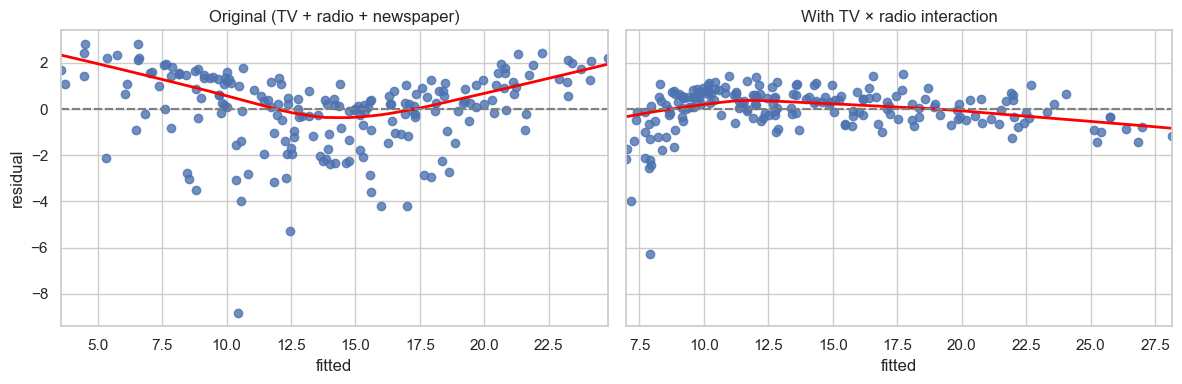

In [53]:
# Residual-vs-fitted plots: original model vs. interaction model
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid,
              lowess=True, ax=ax[0],
              line_kws={'color': 'red', 'lw': 2})
ax[0].axhline(0, color='gray', ls='--')
ax[0].set(title='Original (TV + radio + newspaper)',
          xlabel='fitted', ylabel='residual')

sns.residplot(x=fit_int.fittedvalues, y=fit_int.resid,
              lowess=True, ax=ax[1],
              line_kws={'color': 'red', 'lw': 2})
ax[1].axhline(0, color='gray', ls='--')
ax[1].set(title='With TV \u00d7 radio interaction',
          xlabel='fitted')

plt.tight_layout()
plt.show()

Adjusted $R^2$ jumps from about **0.90 to 0.97**, and the residual plot
becomes dramatically more symmetric — the interaction term was the missing
piece. **Interpretation:** the marginal effect of TV is now
$(\beta_{\text{TV}} + \beta_{\text{TV·radio}} \cdot \text{radio})$ — i.e. the
payoff of one more TV dollar *depends* on the current radio spend.

### 11.4 Weighted Least Squares — A Formal Fix for Heteroscedasticity

If the error variance changes from observation to observation, OLS still
gives unbiased coefficients, but its **standard errors are wrong** — so
p-values and confidence intervals can't be trusted. **Weighted Least
Squares (WLS)** fixes this by giving each observation a weight $w_i$
proportional to the *inverse* of its error variance:

$$\hat{\boldsymbol{\beta}}_{\text{WLS}} \;=\; \arg\min_{\boldsymbol{\beta}}\; \sum_i w_i \bigl(y_i - \mathbf{x}_i^\top \boldsymbol{\beta}\bigr)^2, \quad w_i = 1/\sigma_i^2.$$

In practice we don't know $\sigma_i^2$, so we **estimate** it — a standard
recipe is to regress the squared OLS residuals on $x$ and use the
reciprocal of the prediction as the weight.

In [54]:
# Reuse the heteroscedastic simulated data from section 11.1
ols_sim = sm.OLS(y_h, sm.add_constant(x_h)).fit()

# Estimate variance as a linear function of x
var_hat = sm.OLS(ols_sim.resid ** 2, sm.add_constant(x_h)).fit().fittedvalues
weights = 1.0 / np.clip(var_hat, 1e-6, None)

wls_sim = sm.WLS(y_h, sm.add_constant(x_h), weights=weights).fit()

compare = pd.DataFrame({
    'OLS coef':  ols_sim.params.round(3),
    'OLS SE':    ols_sim.bse.round(3),
    'WLS coef':  wls_sim.params.round(3),
    'WLS SE':    wls_sim.bse.round(3),
}, index=['const', 'x'])
compare

,OLS coef,OLS SE,WLS coef,WLS SE
const,-5.338,1.370,1.606,0.278
x,3.179,0.212,0.792,0.147


Both methods give similar point estimates, but WLS produces **smaller
standard errors** because it down-weights the noisy observations near the
upper tail of $x$. That translates directly into tighter confidence
intervals and more reliable p-values.

### 11.5 Heteroscedasticity-Robust Standard Errors — The One-Line Fix

If you only care about **honest inference** (standard errors, p-values,
CIs) and not a better point estimate, `statsmodels` can recompute the
standard errors with **one extra argument**. No transformation, no
weights, no refit.

The most widely used flavor is **HC3** (a.k.a. MacKinnon–White), which works
well even on small samples.

In [55]:
fit_plain = sm.OLS(y, X_const).fit()
fit_hc3   = sm.OLS(y, X_const).fit(cov_type='HC3')

se_compare = pd.DataFrame({
    'coef':        fit_plain.params.round(4),
    'SE (plain)':  fit_plain.bse.round(4),
    'SE (HC3)':    fit_hc3.bse.round(4),
    'p (plain)':   fit_plain.pvalues.round(4),
    'p (HC3)':     fit_hc3.pvalues.round(4),
})
se_compare

,coef,SE (plain),SE (HC3),p (plain),p (HC3)
const,2.9389,0.3119,0.3420,0.0000,0.0000
TV,0.0458,0.0014,0.0020,0.0000,0.0000
radio,0.1885,0.0086,0.0111,0.0000,0.0000
newspaper,-0.0010,0.0059,0.0066,0.8599,0.8754


Coefficients are **identical** (HC doesn't refit the model), but the
standard errors and p-values adjust to account for heteroscedasticity.
This is the go-to fix whenever you don't want to change the model itself.

### 11.6 Dropping Redundant Predictors — Simplest Multicollinearity Fix

Back in Section 8 the coefficient on `newspaper` had a huge p-value —
once TV and radio were in the model, newspaper added essentially nothing.
The simplest remedy is to **drop it** and compare adjusted $R^2$ (the
honest metric when removing features).

In [56]:
X2 = sm.add_constant(data[['TV', 'radio']])
fit2 = sm.OLS(data['sales'], X2).fit()

print(f"Full (TV, radio, newspaper)  R\u00b2 = {ols_model.rsquared:.4f}   "
      f"Adj R\u00b2 = {ols_model.rsquared_adj:.4f}")
print(f"Reduced (TV, radio)          R\u00b2 = {fit2.rsquared:.4f}   "
      f"Adj R\u00b2 = {fit2.rsquared_adj:.4f}")

Full (TV, radio, newspaper)  R² = 0.8972   Adj R² = 0.8956
Reduced (TV, radio)          R² = 0.8972   Adj R² = 0.8962


Adjusted $R^2$ *improves* when we drop `newspaper` — a cleaner,
simpler, equally-good model. A successful, essentially free, remedial
step.

### 11.7 Ridge Regression — Multicollinearity via Regularization

When two predictors are **almost a copy of each other**, OLS becomes
wildly unstable: the inverse of $X^\top X$ is nearly singular, so tiny
perturbations in the data cause huge swings in the coefficients. **Ridge
regression** adds a penalty on the size of the coefficients,

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} \;=\; \arg\min_{\boldsymbol{\beta}}\; \|y - X\boldsymbol{\beta}\|^2 \;+\; \alpha \|\boldsymbol{\beta}\|^2,$$

which **shrinks** coefficients towards zero. This introduces a small bias
but *massively* reduces variance — a classic bias-variance trade.

We'll demonstrate on two synthetic predictors that are almost identical.

In [57]:
from sklearn.linear_model import LinearRegression as SkLR, Ridge

rng = np.random.default_rng(1)
n_c = 100
x1 = rng.normal(size=n_c)
x2 = x1 + rng.normal(scale=0.02, size=n_c)        # ~ copy of x1
y_c = 3 * x1 - 2 * x2 + rng.normal(scale=0.5, size=n_c)
X_c = np.column_stack([x1, x2])

lr_fit   = SkLR().fit(X_c, y_c)
ridge_fit = Ridge(alpha=1.0).fit(X_c, y_c)

print(f"True coefficients      : [ 3.00, -2.00 ]  (but x1 \u2248 x2)")
print(f"OLS  coefficients      : {lr_fit.coef_.round(2).tolist()}")
print(f"Ridge coefficients     : {ridge_fit.coef_.round(2).tolist()}")
print()
print(f"OLS correlation(x1,x2) : {np.corrcoef(x1, x2)[0,1]:.4f}")

True coefficients      : [ 3.00, -2.00 ]  (but x1 ≈ x2)
OLS  coefficients      : [3.35, -2.35]
Ridge coefficients     : [0.55, 0.44]

OLS correlation(x1,x2) : 0.9997


Because $x_1$ and $x_2$ are almost identical, the individual OLS
coefficients balloon to cancel each other out — OLS is trying to
distinguish two essentially-equal columns and picks an arbitrary split.
Ridge pulls them back to sensible, nearly-equal values. **Takeaway:** when
VIFs are large, prefer regularized estimators (Ridge or Lasso) over raw
OLS if prediction is the goal, or combine the collinear features into
one.

### 11.8 Picking a Remedy — A Decision Flow

Faced with a failing diagnostic, here is a sensible order of operations:

1. **Start with the diagnostics, not the remedy.** Run the full battery
   from Section 10 *before* touching the model.
2. **Fix the most severe violation first.** Non-linearity almost always
   dominates — a bent residual plot makes everything else meaningless.
3. **Prefer structural fixes over band-aids.** A log-transform or an
   interaction term that flattens the residual plot is better than
   slapping HC standard errors on a misspecified model.
4. **Re-run the diagnostics after each fix.** Remedies interact; one can
   create a new problem while solving another.
5. **"Good enough" is good enough.** Perfect normality is *not* required
   for large samples — the Central Limit Theorem kicks in for the
   sampling distribution of $\hat{\boldsymbol{\beta}}$.
6. **Know when to give up on linear regression.** If nothing cleans up
   the residual plot, the tool is wrong. Consider:
   - **GLMs** (Poisson for counts, logistic for binary, gamma for positive
     skewed data),
   - **Generalized Additive Models (GAMs)** for smooth non-linear fits,
   - **Tree-based models** (Random Forest, Gradient Boosting) when
     interpretability is less important than raw accuracy.

## 12. Key Takeaways

1. **Regression is curve fitting with uncertainty.** Linear regression
   picks the straight line / flat plane that minimizes the **sum of
   squared residuals**, giving *unbiased* coefficients under the LINEM
   assumptions.
2. **The derivative-equals-zero trick** finds the minimum because at the
   bottom of a smooth bowl there is no direction to move that decreases
   the value — the tangent is flat. Setting partials to zero yields the
   **normal equations** $X^\top X \boldsymbol{\beta} = X^\top y$.
3. **"Linear" means linear in the coefficients**, not in the inputs. You
   can fit $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 \log x$ with
   OLS — feature engineering is a first-class remedial tool.
4. **`statsmodels` is your friend for inference** — it gives you the full
   OLS summary with standard errors, p-values, confidence intervals and
   diagnostics; `sklearn` is better when you only care about prediction.
5. **Never trust a model you haven't diagnosed.** Residual plots, Q–Q
   plots, VIF, Cook's distance and the formal tests each catch a
   different assumption violation.
6. **Remedies are targeted.** Match the fix to the failing assumption:
   transform $y$ or use WLS/HC for heteroscedasticity; add polynomial or
   interaction terms for non-linearity; drop collinear predictors or use
   Ridge for multicollinearity; use RLM for influential points.
7. **Iterate.** Diagnose → fix → re-diagnose. Stop when the residuals
   look boring and the inference is honest.

## 13. Practice Exercises

Try these on your own — they reuse the same Advertising dataset we loaded
in Section 5. Write your answers as new code cells below.

1. **Simple regression revisited.** Fit a model of `sales` on **only**
   `TV`. What does the slope say about the return on one extra unit of
   TV advertising? Draw the fitted line on top of a scatter plot.
2. **Interaction deep-dive.** Extend the model with `TV × radio`. Does
   the coefficient of the interaction term turn out significant? In
   plain English, what does it mean for the business?
3. **Transforming the response.** Apply $\log(\text{sales})$ as a
   transformation and refit with all three predictors. Does the
   Breusch–Pagan p-value improve? How do you now interpret the TV
   coefficient?
4. **HC standard errors.** Re-fit the full Advertising model using
   `cov_type='HC3'`. Compare the p-value on `newspaper` with the plain
   OLS version — does the verdict change?
5. **WLS from scratch.** On the same Advertising data, estimate
   observation-level variance by regressing the squared OLS residuals on
   `TV + radio`, then re-fit using `sm.WLS` with the inverse predictions
   as weights. Compare the slopes and standard errors.
6. **Ridge on Advertising.** Standardize `TV`, `radio`, `newspaper` and
   fit `sklearn.linear_model.Ridge(alpha=1.0)`. Are the coefficients
   different from OLS? Sweep $\alpha$ from 0 to 100 and plot how each
   coefficient shrinks.
7. **Influential-point hunt.** Construct a synthetic dataset where a
   single point has Cook's distance greater than 1. Refit with and
   without the point, and show how much the slope changes.
8. **Beyond linear.** Take the yield-vs-temperature data from Section 11.2
   and fit `sklearn.ensemble.GradientBoostingRegressor`. Compare its fit
   to the cubic polynomial. Which generalizes better if you add new
   points between the existing ones?